# Google Play Store Analysis — Sustainable Tourism App

This notebook analyzes the Google Play Store dataset with one goal in mind:
understanding the market landscape to support the development of a new app focused on
sustainable tourism, wellness and editorial content.

The analysis follows this structure:
1. Data Cleaning
2. General Dataset Exploration
3. Downloads by Genre
4. Engagement Analysis by Category
5. Outlier Analysis
6. Download Distribution — Target Categories
7. Free vs Paid
8. Correlation Matrix
9. Paid App Pricing

## 1. Data Cleaning

Before any analysis, we clean and standardize the dataset:
- Row 10472 is dropped (the string "Everyone" had ended up in the Price column)
- Price, Installs and Reviews are converted to float
- Last Updated is parsed as datetime
- Size is converted to numeric MB values ("19M" → 19.0, "Varies with device" → NaN)
- Rows with missing Rating are removed, with a report on how many are lost and what percentage they represent

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# ── IMPORT DATASET ────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\Usuario\Desktop\googleplaystore.csv")

# ── DATA CLEANING: PRICE ──────────────────────────────────────────────────────
# La riga 10472 ha 'Everyone' nella colonna Price — la rimuoviamo
df = df.drop(10472)
df['Price'] = df['Price'].str.replace('$', '', regex=False).astype(float)

# ── DATA CLEANING: INSTALLS ───────────────────────────────────────────────────
df['Installs'] = (
    df['Installs']
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# ── DATA CLEANING: REVIEWS ────────────────────────────────────────────────────
df['Reviews'] = df['Reviews'].astype(float)

# ── DATA CLEANING: LAST UPDATED ───────────────────────────────────────────────
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

# ── DATA CLEANING: SIZE → MB numerici ────────────────────────────────────────
def convert_size(val):
    if pd.isna(val) or str(val).strip() == 'Varies with device':
        return np.nan
    val = str(val).strip()
    if val.endswith('M'):
        return float(val[:-1])
    elif val.endswith('k'):
        return float(val[:-1]) / 1024
    return np.nan

df['Size_MB'] = df['Size'].apply(convert_size)

# ── RESET INDEX ───────────────────────────────────────────────────────────────
df = df.reset_index(drop=True)

# ── REMOVE NaN RATING — con reportistica ─────────────────────────────────────
rows_before = len(df)
df = df.dropna(subset=['Rating']).reset_index(drop=True)
rows_lost = rows_before - len(df)
print(f"Righe totali dopo cleaning: {len(df):,}")
print(f"Righe rimosse per NaN in Rating: {rows_lost} ({rows_lost/rows_before*100:.1f}%)")

Righe totali dopo cleaning: 9,366
Righe rimosse per NaN in Rating: 1474 (13.6%)


## 2. General Dataset Exploration

Before diving into specific categories, we describe the dataset as a whole.
How many apps? How many categories? How are the main variables distributed?
This step provides the context needed to interpret everything that follows.

In [11]:
# ── ESPLORAZIONE GENERALE DEL DATASET ────────────────────────────────────────

print(f"App totali:   {df.shape[0]:,}")
print(f"Categorie:    {df['Category'].nunique()}")
print(f"Generi:       {df['Genres'].nunique()}")
print()
df.info()
print()
df[['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']].describe().round(2)

App totali:   9,366
Categorie:    33
Generi:       115

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9366 entries, 0 to 9365
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             9366 non-null   object        
 1   Category        9366 non-null   object        
 2   Rating          9366 non-null   float64       
 3   Reviews         9366 non-null   float64       
 4   Size            9366 non-null   object        
 5   Installs        9366 non-null   float64       
 6   Type            9366 non-null   object        
 7   Price           9366 non-null   float64       
 8   Content Rating  9366 non-null   object        
 9   Genres          9366 non-null   object        
 10  Last Updated    9366 non-null   datetime64[ns]
 11  Current Ver     9362 non-null   object        
 12  Android Ver     9364 non-null   object        
 13  Size_MB         7729 non-null   float64       
dtype

,Rating,Reviews,Installs,Price,Size_MB
count,9366.00,9366.00,9.366000e+03,9366.00,7729.00
mean,4.19,514049.84,1.789744e+07,0.96,22.96
std,0.52,3144042.13,9.123822e+07,15.82,23.45
min,1.00,1.00,1.000000e+00,0.00,0.01
25%,4.00,186.25,1.000000e+04,0.00,5.30
50%,4.30,5930.50,5.000000e+05,0.00,14.00
75%,4.50,81532.75,5.000000e+06,0.00,33.00
max,5.00,78158306.00,1.000000e+09,400.00,100.00


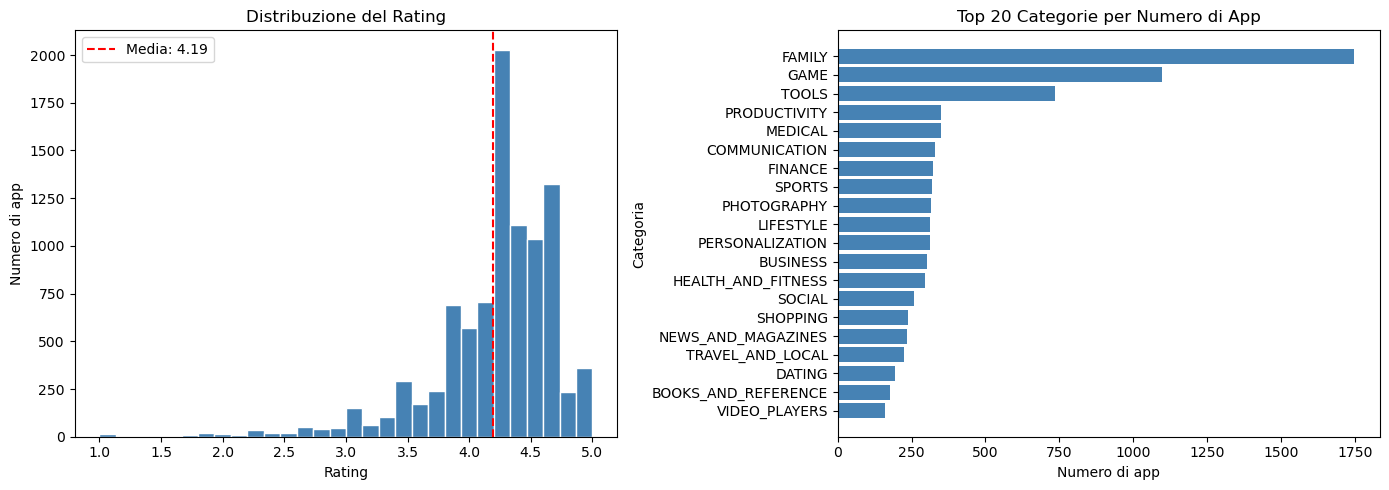

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione del Rating
axes[0].hist(df['Rating'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuzione del Rating', fontsize=12)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Numero di app')
axes[0].axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Media: {df['Rating'].mean():.2f}")
axes[0].legend()

# Numero di app per categoria (top 20)
cat_counts = df['Category'].value_counts().head(20)
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='steelblue')
axes[1].set_title('Top 20 Categorie per Numero di App', fontsize=12)
axes[1].set_xlabel('Numero di app')
axes[1].set_ylabel('Categoria')

plt.tight_layout()
plt.show()

## 3. Total Downloads by Genre

We aggregate total installs by genre to understand which segments of the market
attract the most users. Color represents the number of apps in each genre,
allowing us to distinguish between genres dominated by a few giants
and those with more distributed competition.

In [15]:
# Somma del numero di downloads per genere
df_installs = df.groupby('Genres')['Installs'].agg(['sum','count']).reset_index().sort_values(by='sum', ascending=False).head(20)

order = df_installs.sort_values('sum', ascending=False)['Genres']

fig = px.bar(
    df_installs,
    x='Genres',
    y='sum',
    color='count',
    category_orders={'Genres': order},
    title='Number of downloads per genre'
)

fig.show()

Communication leads by a wide margin, driven by a handful of global platforms (WhatsApp, Gmail, etc.).
Productivity and Social follow. These are mature, saturated markets.
Travel & Local and News & Magazines sit in the mid-range — meaningful volume,
but no single dominant player, which signals opportunity.
 

## 4. Engagement Analysis by Category

We define engagement as the percentage of users who leave a review after downloading an app:

`engagement = (Reviews / Installs) * 100`

This metric goes beyond star ratings — it measures how much users care enough to interact.
Methodological choices:
- Apps with fewer than 1,000 installs are excluded (too little traffic to be meaningful)
- Categories with fewer than 150 apps are excluded (sample too small for reliable comparisons)
- We use the median instead of the mean to limit the effect of outliers

In [16]:
df_enga = df.copy()

# Filtro app con almeno 1000 downloads
df_enga = df_enga[df_enga['Installs'] > 1000]

# Engagement in percentuale, quanti lasciano reviews dopo aver scaricato l'app
df_enga['perc_eng'] = (df_enga['Reviews'] / df_enga['Installs']) * 100

# Raggruppo per categoria
df_cat_enga = (
    df_enga
    .groupby('Category')
    .agg(
        median_perc_eng=('perc_eng', 'median'),
        mean_rating=('Rating', 'mean'),
        app_count=('App', 'count')
    )
    .reset_index()
)

# Categorie con almeno 150 app al fine di essere statisticamente rilevante
df_cat_enga = df_cat_enga[df_cat_enga['app_count'] >= 150]

df_cat_enga = df_cat_enga.sort_values('median_perc_eng', ascending=False)

df_cat_enga

,Category,median_perc_eng,mean_rating,app_count
14,GAME,2.920525,4.285146,1030
27,SOCIAL,2.445600,4.245852,229
15,HEALTH_AND_FITNESS,2.292140,4.299228,259
28,SPORTS,2.173300,4.242105,285
8,EDUCATION,2.118560,4.383660,153
6,COMMUNICATION,2.070000,4.168729,291
12,FINANCE,2.063600,4.156985,272
21,NEWS_AND_MAGAZINES,1.877080,4.093000,200
7,DATING,1.850000,3.968485,165
26,SHOPPING,1.819830,4.253846,221


In [17]:
fig = px.scatter(
    df_cat_enga,
    x='median_perc_eng',
    y='mean_rating',
    size='app_count',
    color='Category',
    hover_name='Category',
    log_x=True,
    title='Download / Review efficiency vs Rating'
)

fig.update_xaxes(title='Median review per installs (%)')
fig.update_yaxes(title='Average rating')

fig.show()

The scatter plot shows engagement on the x-axis (log scale) and average rating on the y-axis.
Bubble size represents the number of apps in each category.
Categories in the top-right corner combine high engagement and high rating — the ideal benchmark.
Our target categories (Travel, Health, News) sit in interesting positions:
moderate engagement with room to grow, which confirms there is space for a product
that builds a more active and loyal user community.

## 5. Outlier Analysis

We analyze outliers on the four main numeric variables using the IQR method:
a value is flagged as an outlier if it falls below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

Important: this analysis is performed on individual app values, not on category averages.
A boxplot on ~30 aggregated values (one per category) is not statistically informative enough
to detect outliers reliably.

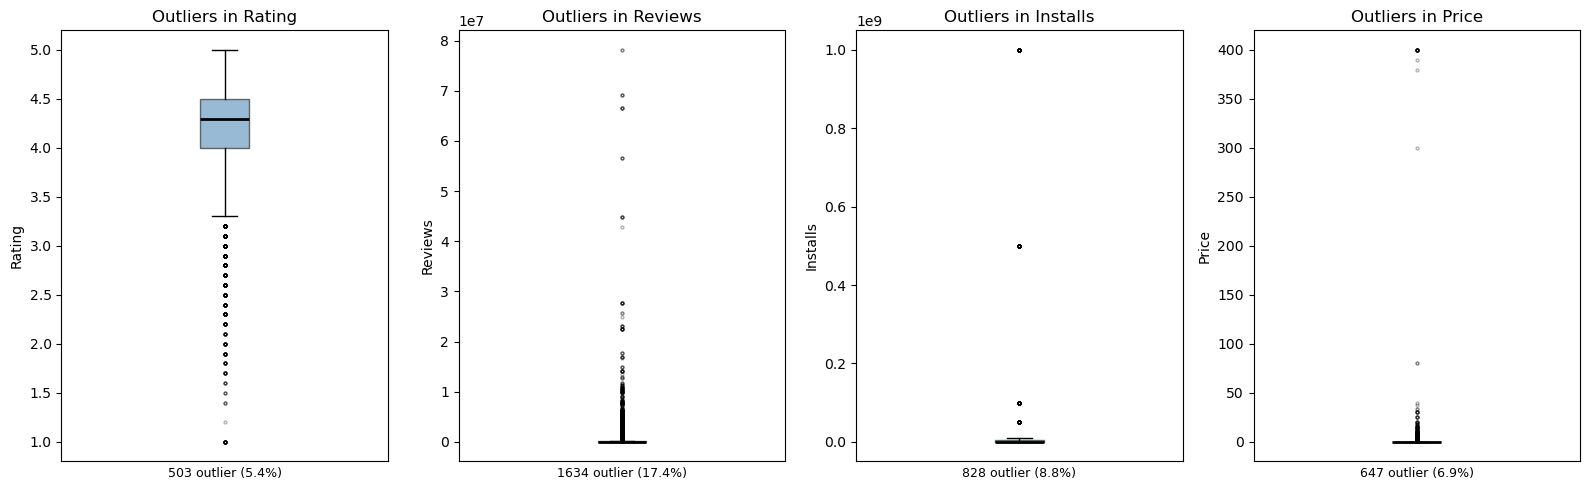

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, var, color in zip(axes,
                           ['Rating', 'Reviews', 'Installs', 'Price'],
                           ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']):
    data = df[var].dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.55),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    n_out = ((data < q1 - 1.5*(q3-q1)) | (data > q3 + 1.5*(q3-q1))).sum()
    ax.set_title(f'Outliers in {var}')
    ax.set_ylabel(var)
    ax.set_xticks([])
    ax.set_xlabel(f'{n_out} outlier ({n_out/len(data)*100:.1f}%)', fontsize=9)

plt.tight_layout()
plt.show()

Results:
- **Rating** — compact distribution, few outliers on the lower end. Most apps cluster between 4.0 and 5.0
- **Reviews** — strongly right-skewed. A small number of apps accumulate millions of reviews while the median is very low
- **Installs** — even more extreme than Reviews. A handful of apps dominate with billions of downloads
- **Price** — almost all apps are free (Price = 0), so any paid app appears as an outlier by definition

These findings confirm why we use the median rather than the mean in all comparative analyses.

## 6. Download Distribution — Target Categories

We compare the download distribution across our three target categories
(Travel & Local, News & Magazines, Health & Fitness) against the full dataset.
The x-axis uses a logarithmic scale to handle the extreme range of values.

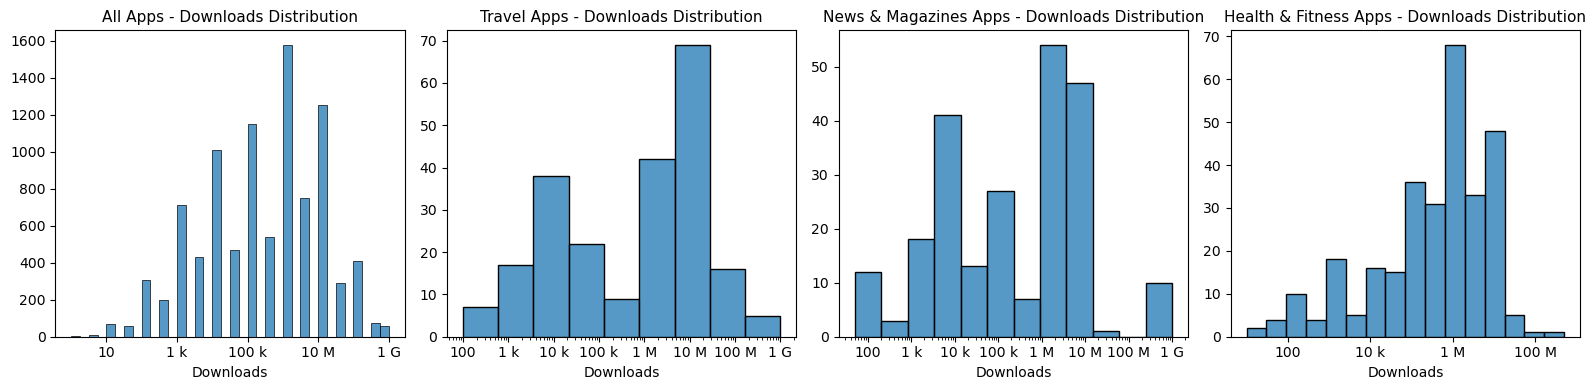

In [24]:
from matplotlib.ticker import EngFormatter

# Filtro per categorie interessate
df_travel = df[df.Genres=='Travel & Local'].copy()
df_magazines = df[df.Genres=='News & Magazines'].copy()
df_health = df[df.Genres=='Health & Fitness'].copy()


fig, ax = plt.subplots(1, 4, figsize=(16, 4))

# Primo subplot - df
sns.histplot(df['Installs'], log_scale=True, ax=ax[0])
ax[0].set_title('All Apps - Downloads Distribution', fontsize=11)
ax[0].set_xlabel('Downloads')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(EngFormatter())

# Secondo subplot - df_travel
sns.histplot(df_travel['Installs'], log_scale=True, ax=ax[1])
ax[1].set_title('Travel Apps - Downloads Distribution', fontsize=11)
ax[1].set_xlabel('Downloads')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(EngFormatter())

# Terzo subplot - df_communication

sns.histplot(df_magazines['Installs'], log_scale=True, ax=ax[2])
ax[2].set_title('News & Magazines Apps - Downloads Distribution', fontsize=11)
ax[2].set_xlabel('Downloads')
ax[2].set_ylabel('')
ax[2].xaxis.set_major_formatter(EngFormatter())

# Quarto subplot - df_health

sns.histplot(df_health['Installs'], log_scale=True, ax=ax[3])
ax[3].set_title('Health & Fitness Apps - Downloads Distribution', fontsize=11)
ax[3].set_xlabel('Downloads')
ax[3].set_ylabel('')
ax[3].xaxis.set_major_formatter(EngFormatter())

plt.tight_layout()
plt.show()




All Apps shows a bimodal distribution — many apps with few downloads and a long tail of very popular ones.
Travel & Local and News & Magazines have similar shapes, with most apps concentrated
in the 10K–1M range. Health & Fitness shows a tighter, more homogeneous distribution —
demand is solid and spread across many apps rather than concentrated in a few giants.
This makes it the most accessible category for a new entrant.

## 7. Apps by Download Range — Target Categories

We group apps into download brackets to make the comparison more concrete.
This gives us a clearer picture of where most competition sits
and what a realistic first-year target looks like.

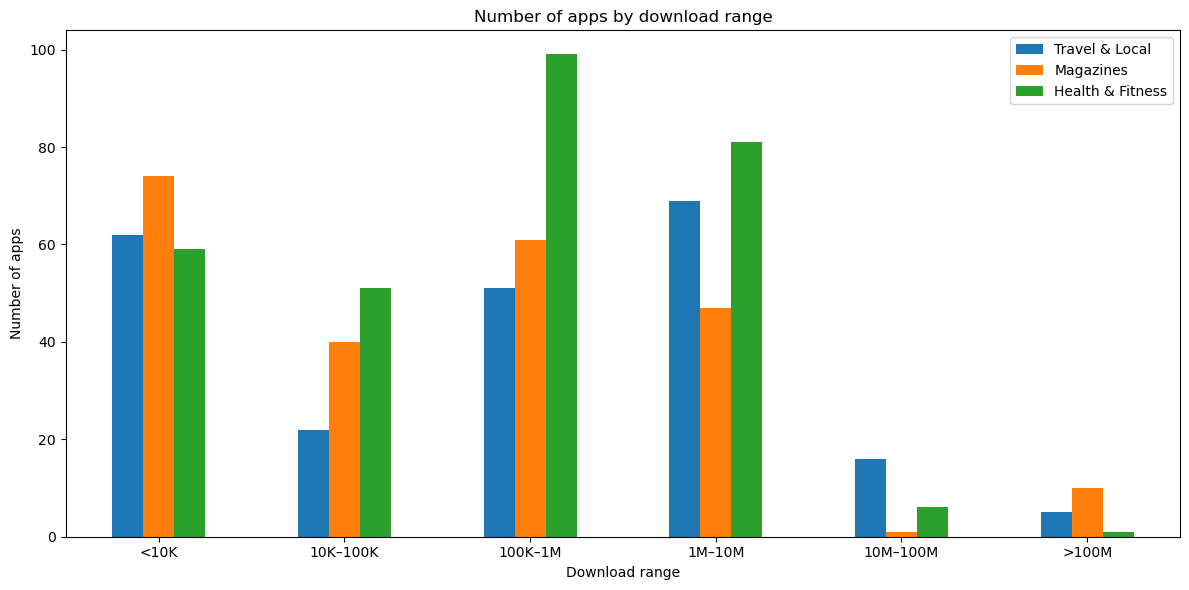

In [20]:
bins   = [0, 1e4, 1e5, 1e6, 1e7, 1e8, np.inf]
labels = ['<10K', '10K–100K', '100K–1M', '1M–10M', '10M–100M', '>100M']

df_travel['install_range']    = pd.cut(df_travel['Installs'],    bins=bins, labels=labels)
df_magazines['install_range'] = pd.cut(df_magazines['Installs'], bins=bins, labels=labels)
df_health['install_range']    = pd.cut(df_health['Installs'],    bins=bins, labels=labels)

travel_counts    = df_travel['install_range'].value_counts().sort_index()
magazines_counts = df_magazines['install_range'].value_counts().sort_index()
health_counts    = df_health['install_range'].value_counts().sort_index()

plot_df = pd.DataFrame({
    'Travel & Local':   travel_counts,
    'Magazines':        magazines_counts,
    'Health & Fitness': health_counts
}).fillna(0)

plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Number of apps by download range')
plt.xlabel('Download range')
plt.ylabel('Number of apps')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The majority of apps in all three categories fall in the 10K–1M range.
Very few reach beyond 10M downloads. This anchors our target of 100,000 downloads
in the first year as ambitious but realistic — it sits in the most populated bracket,
meaning it is achievable without needing to outperform established market leaders.

## 8. Free vs Paid Distribution

We look at the proportion of free and paid apps across our target categories
compared to the overall dataset. This directly informs the monetization strategy.

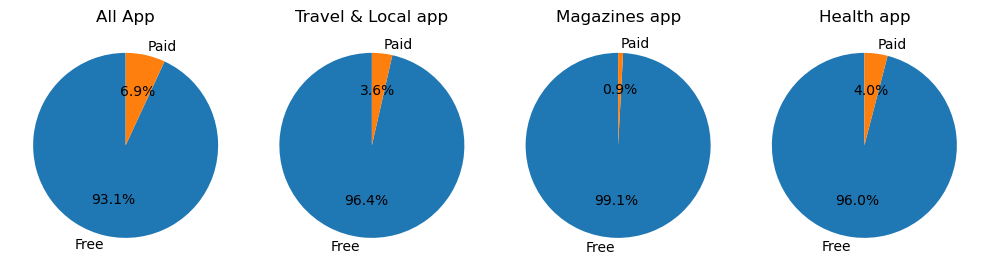

In [13]:
fig, ax = plt.subplots(1,4, figsize=(10,8))

df_type = df.Type.value_counts()
df_travel_type = df_travel.Type.value_counts()
df_magazines_type = df_magazines.Type.value_counts()
df_health_type = df_health.Type.value_counts()


df_type.plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[0], title='All App')
df_travel_type.plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[1], title='Travel & Local app')
df_magazines_type.plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[2], title='Magazines app')
df_health_type.plot(kind='pie', startangle=90, autopct='%1.1f%%', ax=ax[3], title='Health app')


ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[2].set_ylabel('')
ax[3].set_ylabel('')


fig.tight_layout()
plt.show()


In all three target categories, over 90% of apps are free.
This is consistent with the overall market. Users in Travel, Health and News
are not accustomed to paying upfront. A freemium model — free core experience
with premium features available through subscription or in-app purchases — is
the clear standard and the right strategic choice for our app.

## 9. Correlation Matrix

We calculate the correlation between the main numeric variables to understand
how they relate to each other. Key questions:
- Do apps with more downloads tend to have better ratings?
- Does price affect the number of installs?
- Is app size related to engagement?

Note: Reviews and Installs are log-transformed before the calculation
to reduce the effect of their strongly skewed distributions.

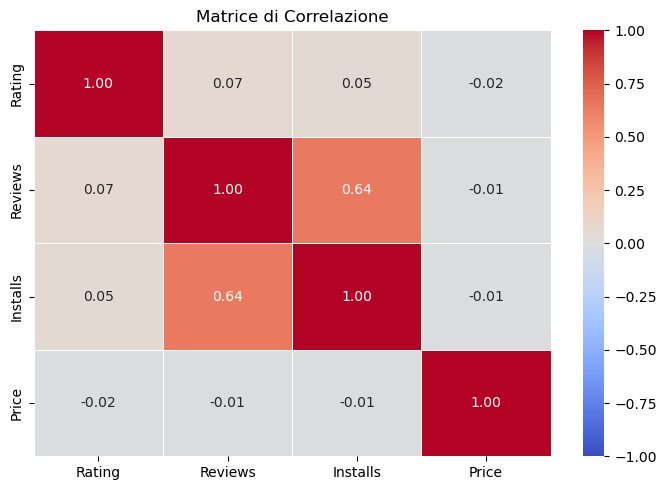

In [ ]:
corr = df[['Rating', 'Reviews', 'Installs', 'Price']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matrice di Correlazione')
plt.tight_layout()
plt.show()

Key findings:
- Rating and log_Installs show a moderate positive correlation — more popular apps
  tend to be rated slightly better, but the relationship is not deterministic
- Price and log_Installs show a negative correlation — confirming that paid apps
  get significantly fewer downloads, which supports the freemium model
- Reviews and Installs are strongly correlated, as expected — more downloads naturally
  generate more reviews

## 10. Paid App Pricing by Category

Among paid apps, we look at the median price per category
to understand where users are willing to spend money and how much.

In [23]:
# Prezzo mediano per categoria (solo app a pagamento)
df_paid = df[df['Type'] == 'Paid']

df_paid_content_price = df_paid.groupby('Category')['Price'].median().reset_index().sort_values(by='Price', ascending=False).head(15)
fig = px.bar(df_paid_content_price, x='Category', y='Price', title='Median app price divided by Categories')
fig.show()

The most expensive categories — Finance, Medical, Dating — target adult users
with purchasing power and specific professional or personal needs.
Our app targets a sustainability-conscious adult audience, but given the abundance
of free information available online, the freemium model remains the right choice.
Premium revenue should come from in-app services, exclusive content and
eco-certified partner integrations rather than an upfront price.

## Conclusions

This analysis confirms that there is a real market opportunity for a new app
combining sustainable tourism, wellness and editorial content.

**What the data shows:**
- Travel & Local and News & Magazines have below-average ratings — users are not fully satisfied with existing options
- Health & Fitness has stable, distributed demand — a good complementary category to include
- Over 90% of apps in all target categories are free — freemium is the market standard
- Engagement analysis shows there is room to build a more active user community than current apps offer
- Paid apps get significantly fewer installs — pricing must be optional, not a barrier to entry

**What I interpret (beyond the data):**
Below-average ratings in Travel and Magazines could reflect unmet expectations,
technical issues, or simply a higher bar users set for these categories.
The data alone cannot tell us which — but it does confirm that the current offer
is not fully satisfying users, which is where our app can make a difference.

**The proposal — EcoWander:**
A freemium app with sustainable travel guides, wellness content and editorial articles.
Monetization through premium subscription and eco-certified partner integrations.
First-year target: 100,000 downloads — realistic based on the download distribution
observed in the Travel & Local category.